In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preliminary: Updated Data Loading

* Task a

In [2]:
data = pd.read_csv("data_HW3.csv")
data.head()

,patient_id,age,sex,weight,blood_type,current_location,num_of_siblings,happiness_score,household_income,conversations_per_day,...,PCR_02,PCR_03,PCR_04,PCR_05,PCR_06,PCR_07,PCR_08,PCR_09,PCR_10,contamination_level
0,733,31,F,80.8,O-,"('11.93381', '79.82979')",6,6,0.7,5,...,5.198138,108.036437,188.801048,4.794950,8.763805,1.664061,10.239285,2.399066,-253.987710,0.327102
1,382,29,F,63.0,O+,"('51.67822', '33.9162')",1,9,NaN,11,...,5.721030,-106.885392,9.936129,1.700335,7.266007,3.071229,5.916312,2.860534,154.620882,0.196443
2,1164,44,F,74.2,O+,"('60.02427', '30.28491')",2,10,1.5,3,...,4.364061,8.145824,46.805718,5.640838,8.647514,3.649969,1.185047,4.834962,106.257677,0.077727
3,897,9,M,31.8,O-,"('51.08468', '7.11393')",3,9,0.5,8,...,0.852508,63.603672,86.119489,8.245630,8.559101,4.537883,0.303430,1.486220,81.953230,0.172861
4,1187,18,F,42.4,A-,"('38.45598', '48.87498')",0,8,0.2,4,...,3.993688,-46.825379,191.552737,6.121042,6.202387,2.250050,8.499374,4.053463,-85.240560,0.367014


* Task b + c

In [3]:
from prepare import prepare_data
from sklearn.model_selection import train_test_split
# Splitting to train and test sets
state = 4+76
train_df, test_df = train_test_split(data, test_size=0.2, random_state=state)
# Taking only pcr features
all_features = data.columns.tolist() 
pcr_features = [feature for feature in all_features if feature.startswith("PCR")] + ["contamination_level"]
# Prepare training set according to itself
train_df_prepared = prepare_data(train_df, train_df)[pcr_features]

# Prepare test set according to the raw training set
test_df_prepared = prepare_data(train_df, test_df)[pcr_features]


# Loading prepared data to csv files
train_df_prepared.to_csv("prepared_data/prepared_train_data.csv",index= False)
test_df_prepared.to_csv("prepared_data/prepared_test_data.csv",index= False)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\HW3_WET\prepare.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_copy["household_income"].fillna(replacement_value,inplace = True)
C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\HW3_WET\prepare.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace m

* Checking

In [4]:
train_df = pd.read_csv("prepared_data/prepared_train_data.csv")
test_df = pd.read_csv("prepared_data/prepared_test_data.csv")
train_df.head()

,PCR_01,PCR_02,PCR_03,PCR_04,PCR_05,PCR_06,PCR_07,PCR_08,PCR_09,PCR_10,contamination_level
0,-0.319564,-0.938708,0.095833,-0.080588,-0.211693,-1.265944,-0.154870,-0.066155,2.040026,-0.211329,0.096351
1,-1.304385,-0.915717,-0.577759,1.010946,-0.865854,-0.042536,-0.734147,-0.567384,-1.895055,0.532303,0.317113
2,0.324314,2.297171,0.764570,0.762770,-0.695165,1.466016,-0.228026,0.744201,0.971091,0.814198,-0.120513
3,-0.699246,-1.172286,0.051257,0.475773,-0.312904,0.226226,0.348053,-0.941917,0.323985,0.285240,0.396919
4,-0.830385,0.124843,-0.145271,1.932064,-0.932569,1.546453,1.133531,-0.598434,-0.242652,-0.014333,0.397551


# Section 1: Linear regression implementation

* Data splitting for this section

In [5]:
s1_test_df = test_df
s1_train_df, s1_val_df = train_test_split(train_df, test_size=0.2, random_state=state)

In [6]:
s1_test_df.shape, s1_train_df.shape, s1_val_df.shape

((250, 11), (800, 11), (200, 11))

* Implementation 

In [7]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class LinearRegressor(BaseEstimator, RegressorMixin):
    """
    Custom linear regression model
    """
    def __init__(self, lr: float = 1e-5):
        """
        Initialize an instance of this class.
        ** Do not edit this method **

        :param lr: the SGD learning rate (step size)
        """
        self.lr = lr
        self.batch_size = 32
        self.w = None
        self.b = 0.0

    # Initialize a random weight vector
    def init_solution(self, n_features: int):
        """
        Randomize an initial solution (weight vector)
        ** Do not edit this method **

        :param n_features:
        """
        self.w = np.zeros(n_features)
        self.b = 0.0

    @staticmethod
    def loss(w, b: float, X, y):
        """
        Compute the MSE objective loss.

        :param w: weight vector for linear regression; array of shape (n_features,)
        :param b: bias scalar for linear regression
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: the linear regression objective loss (float scalar)
        """

        # TODO: complete the loss calculation
        m = len(X)
        inner_term = np.dot(X,w)+ b - y
        loss = (1/m)*(np.linalg.norm(inner_term))**2

        return loss

    @staticmethod
    def gradient(w, b: float, X, y):
        """
        Compute the (analytical) linear regression objective gradient.

        :param w: weight vector for linear regression; array of shape (n_features,)
        :param b: bias scalar for linear regression
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: a tuple with (the gradient of the weights, the gradient of the bias)
        """
        # TODO: calculate the analytical gradient w.r.t w and b
        # prep
        # converting X from DataFrame to NumPy array
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        
        # converting y from Series to NumPy array
        if isinstance(y, pd.Series):
            y = y.to_numpy()

        # w_grad calculation
        m = len(X)
        predictions = np.dot(X,w) +b
        inner_term_w = predictions - y
        g_w = (2/m)*(np.dot(X.T,inner_term_w))
        
        
        # b_grad calculation
        inner_term_b = inner_term_w - b
        g_b = 2*(b + (1/m)*np.sum(inner_term_b))

        return g_w, g_b

    def fit_with_logs(self, X, y, max_iter: int = 1000, keep_losses: bool = True,
                      X_val  =None, y_val = None):
        """
        Fit the model according to the given training data.

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets; array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        :param keep_losses: should compute the train & val losses during training?
        :param X_val: validation samples to compute the loss for (for logs only)
        :param y_val: validation labels to compute the loss for (for logs only)
        :return: training and validation losses during training
        """
        # Initialize learned parameters
        self.init_solution(X.shape[1])

        train_losses = []
        val_losses = []

        if keep_losses:
            train_losses.append(self.loss(self.w, self.b, X, y))
            val_losses.append(self.loss(self.w, self.b, X_val, y_val))

        # Iterate over batches (SGD)
        for itr in range(0, max_iter):
            start_idx = (itr * self.batch_size) % X.shape[0]
            end_idx = min(X.shape[0], start_idx + self.batch_size)
            batch_X = X[start_idx: end_idx]
            batch_y = y[start_idx: end_idx]

            # TODO: Compute the gradient for the current *batch*
            g_w, g_b =  self.gradient(self.w, self.b, batch_X, batch_y)

            # Perform a gradient step
            # TODO: update the learned parameters correctly
            self.w = self.w - self.lr * g_w
            self.b = self.b - self.lr * g_b

            if keep_losses:
                train_losses.append(self.loss(self.w, self.b,  X, y))
                val_losses.append(self.loss(self.w, self.b,  X_val, y_val))

        return train_losses, val_losses

    def fit(self, X, y, max_iter: int = 1000):
        """
        Fit the model according to the given training data.
        ** Do not edit this method **

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets; array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        """
        self.fit_with_logs(X, y, max_iter=max_iter, keep_losses=False)

        return self

    def predict(self, X):
        """
        Regress labels on samples in X.

        :param X: samples for prediction; array of shape (n_samples, n_features)
        :return: Predicted continuous labels for samples in X; array of shape (n_samples,)
        """

        # TODO: Compute
        y_pred = np.dot(X, self.w) + self.b

        return y_pred

* Question 2

In [8]:
import matplotlib.pyplot as plt

def numerical_subgradient(w, b, X, y, delta=1e-4):
    w_ = w.copy()
    g_w = np.zeros_like(w_)
    orig_objective = LinearRegressor.loss(w_, b, X, y)
    for i in range(g_w.shape[0]):
        w_[i] += delta
        perturbed_objective = LinearRegressor.loss(w_, b, X, y)
        w_[i] -= delta
        g_w[i] = (perturbed_objective - orig_objective) / delta

    g_b = (LinearRegressor.loss(w_, b + delta, X, y) - orig_objective) / delta
    return g_w, g_b


def compare_gradients(X, y, deltas, C=1, REPEATS=10, figsize=(10, 6)):
    residual_means_w = []
    residual_means_b = []

    for delta in deltas:
        residuals_w = []
        residuals_b = []

        for _ in range(REPEATS):
            # Randomize vectors in which the gradient is computed
            w = np.random.randn(X.shape[1])
            b = np.random.randn(1)

            # Compute the two types of gradients
            analytic_grad_w, analytic_grad_b = LinearRegressor.gradient(w, b, X, y)

            numeric_grad_w, numeric_grad_b = numerical_subgradient(w, b, X, y, delta=delta)

            residual_w = np.linalg.norm(numeric_grad_w - analytic_grad_w)
            residuals_w.append(residual_w)

            residual_b = np.linalg.norm(numeric_grad_b - analytic_grad_b)
            residuals_b.append(residual_b)

        residual_means_w.append(np.mean(residuals_w))
        residual_means_b.append(np.mean(residuals_b))

    fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(16, 8))
    plt.suptitle('Residuals of analytical and numerical gradients',
                 fontsize=22, fontweight="bold")
    axs[0].set_title(r'Residuals of $\nabla_{w}L\left(w,b\right)$')
    axs[1].set_title(r'Residuals of $\frac{\partial}{\partial{b}}L\left(w,b\right)$')
    axs[0].plot(deltas, residual_means_w, linewidth=3)
    axs[1].plot(deltas, residual_means_b, linewidth=3)
    axs[0].set_yscale('log')
    axs[0].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xscale('log')
    axs[0].set_xlabel('$\delta_w$', fontsize=18)
    axs[1].set_xlabel('$\delta_b$', fontsize=18)
    axs[0].set_ylabel(r'$\left\Vert \nabla_{w}L\left(w,b\right) - u_{\delta_w} \left(w,b\right)\right\Vert$',
                      fontsize=18)
    axs[1].set_ylabel(
        r'$\left\Vert \frac{\partial}{\partial{b}}L\left(w,b\right) - u_{\delta_b} \left(w,b\right)\right\Vert$',
        fontsize=18)

    axs[0].grid(alpha=0.5)
    axs[1].grid(alpha=0.5)
    plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kingh\AppData\Local\Temp\ipykernel_48764\2099208551.py:55: SyntaxWarning: invalid escape sequence '\d'
  axs[0].set_xlabel('$\delta_w$', fontsize=18)
C:\Users\kingh\AppData\Local\Temp\ipykernel_48764\2099208551.py:56: SyntaxWarning: invalid escape sequence '\d'
  axs[1].set_xlabel('$\delta_b$', fontsize=18)


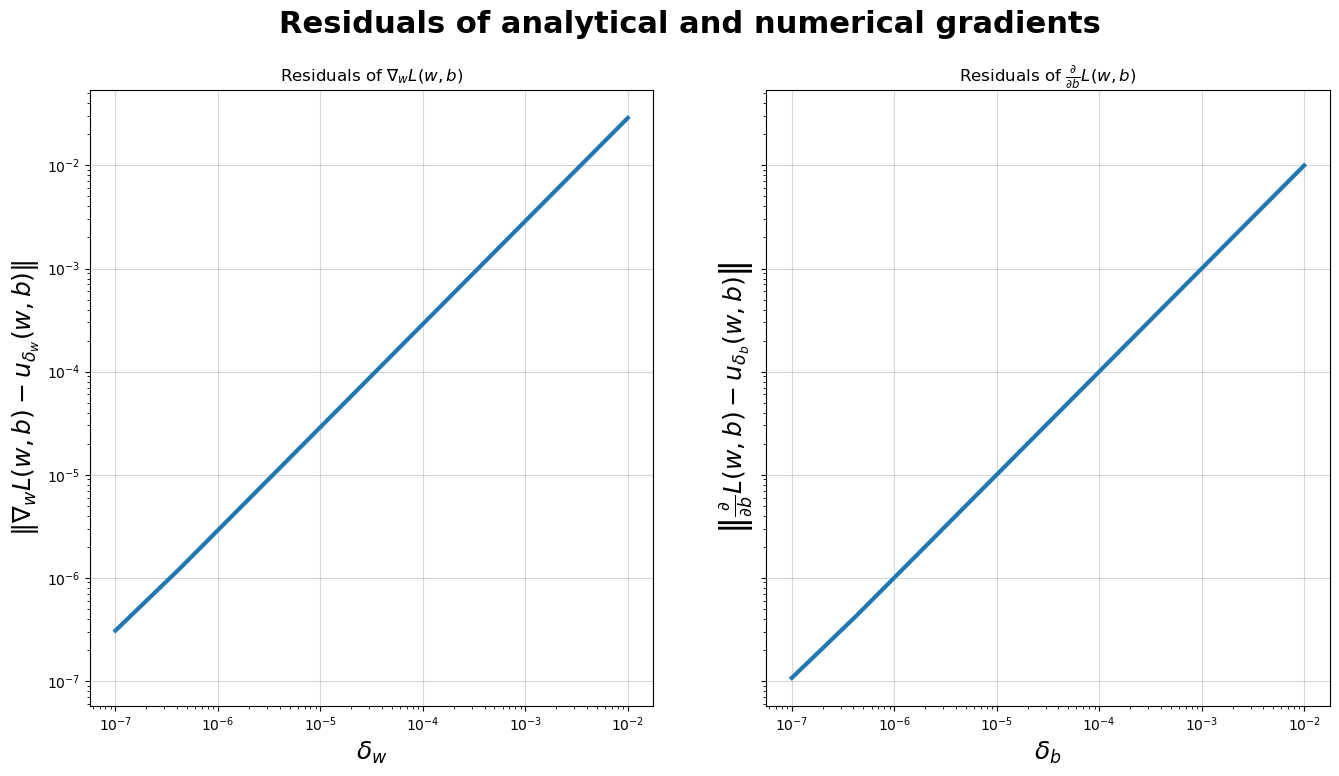

In [9]:
X_train = s1_train_df.drop(["contamination_level"],axis=1)
y_train = s1_train_df["contamination_level"]

compare_gradients(X_train, y_train, deltas=np.logspace(-7, -2, 9))

* Question 3

In [10]:
def test_lr(X_train, y_train, X_val, y_val, title:str, max_iter = 1500):
  lr_list = np.logspace(-9, -1, 9)

  fig, axs = plt.subplots(3, 3, sharey=True, figsize=(20, 12))
  plt.suptitle(title, fontsize=32)
  plt.tight_layout()
  fig.subplots_adjust(hspace=0.5, top=0.9)
  
  axs = np.ravel(axs)
  for i, lr in enumerate(lr_list):
    cur_linear_reggressor = LinearRegressor(lr)
    train_losses, val_losses = cur_linear_reggressor.fit_with_logs(X_train, y_train, keep_losses=True, X_val=X_val, y_val=y_val, max_iter = max_iter)
    print('lr size = '+str(lr)+', Best train loss = '+str(min(train_losses))+', Best validation loss = '+str(min(val_losses)))

    iterations = np.arange(max_iter + 1)
    axs[i].semilogy(iterations, train_losses, label="Train")
    axs[i].semilogy(iterations, val_losses, label="Validation")
    axs[i].grid(alpha=0.5)
    axs[i].legend()
    axs[i].set_title('lr = '+str(lr))
    axs[i].set_xlabel('iteration')
    axs[i].set_ylabel('MSE')

lr size = 1e-09, Best train loss = 0.07631351895494184, Best validation loss = 0.08555616713470707
lr size = 1e-08, Best train loss = 0.07631064407314496, Best validation loss = 0.08555315558374867
lr size = 1e-07, Best train loss = 0.07628190377997457, Best validation loss = 0.08552304891417745
lr size = 1e-06, Best train loss = 0.0759953516165901, Best validation loss = 0.08522286446002557
lr size = 1e-05, Best train loss = 0.07321322101883175, Best validation loss = 0.08230751059298688
lr size = 0.0001, Best train loss = 0.05227381597739127, Best validation loss = 0.060302988271156405
lr size = 0.001, Best train loss = 0.022724319344086995, Best validation loss = 0.02869937498193159
lr size = 0.01, Best train loss = 0.022548071172539496, Best validation loss = 0.0283671790405016
lr size = 0.1, Best train loss = 0.02268955267400382, Best validation loss = 0.027956543466381024


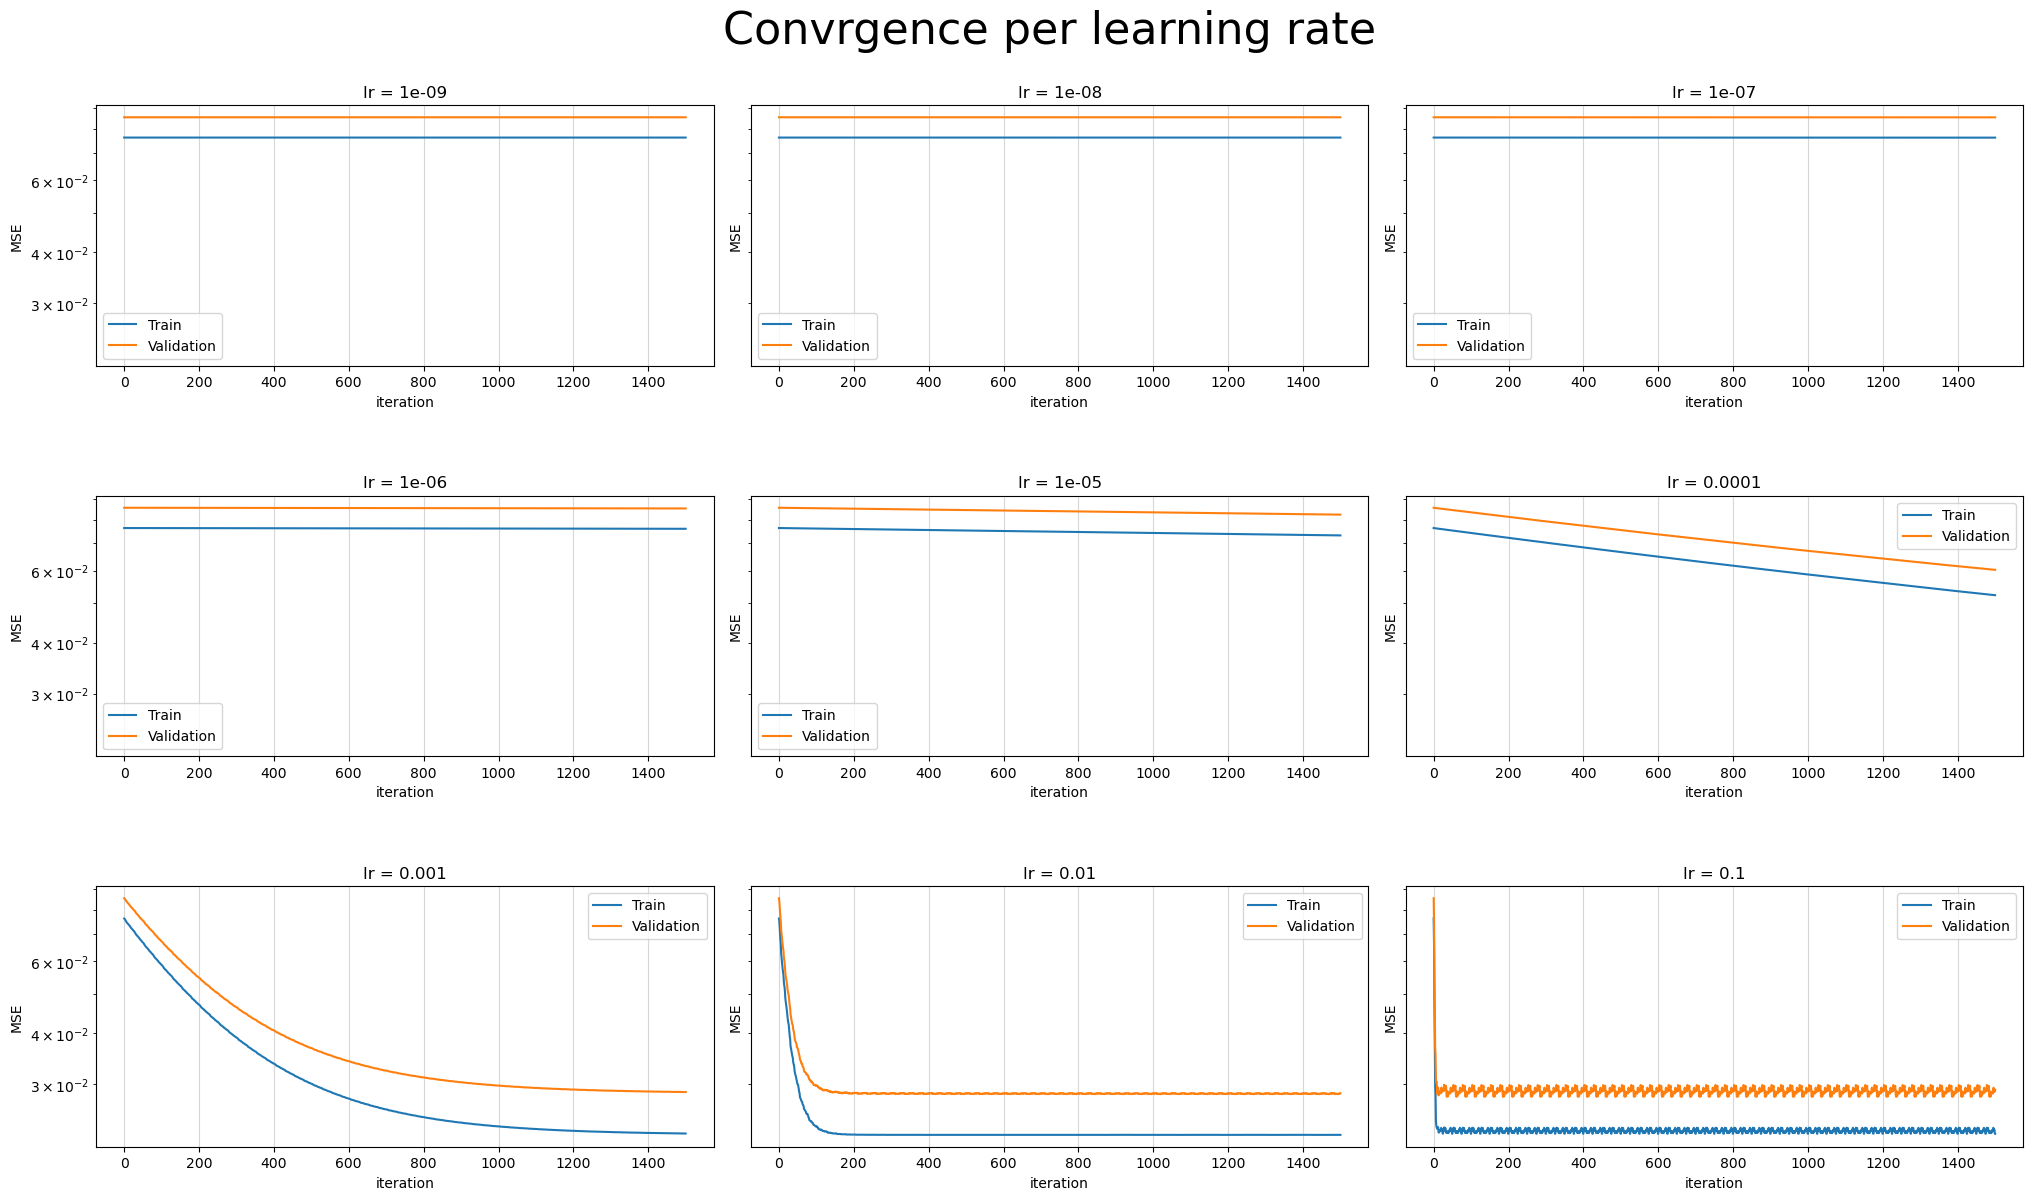

In [11]:
X_train = s1_train_df.drop(["contamination_level"],axis=1)
y_train = s1_train_df["contamination_level"]

X_val = s1_val_df.drop(["contamination_level"],axis=1)
y_val = s1_val_df["contamination_level"]
test_lr(X_train = X_train, y_train = y_train, X_val= X_val, y_val= y_val,title="Convrgence per learning rate")

# Section 2: Evaluation and Baseline

* Data Preperation

In [12]:
train_df = pd.read_csv("prepared_data/prepared_train_data.csv")
test_df = pd.read_csv("prepared_data/prepared_test_data.csv")
s2_entire_train_df = train_df.copy()
s2_test_df = test_df.copy()
s2_train_df, s2_val_df = train_test_split(s2_entire_train_df, test_size=0.2, random_state=state)

* Question 4

In [13]:
from sklearn.model_selection import cross_validate
from sklearn.dummy import DummyRegressor

dum = DummyRegressor()
X_train = s2_train_df.drop(["contamination_level"],axis=1)
y_train = s2_train_df["contamination_level"]
cv_results = cross_validate(dum,
                            X = X_train,
                            y = y_train,
                            cv=5,
                            scoring='neg_mean_squared_error',
                           return_train_score=True)
mean_valid_score = cv_results["test_score"].mean()
mean_train_score = cv_results["train_score"].mean()
print(f"mean validation score is : { mean_valid_score}, mean train score is : { mean_train_score} ")


mean validation score is : -0.06655387736460414, mean train score is : -0.06624823283856855 


* Dummy retraining on entire training set

In [14]:
dummy_regressor = DummyRegressor().fit(X = s2_entire_train_df.drop(["contamination_level"],axis=1),
                                      y = s2_entire_train_df["contamination_level"])


* Question 5

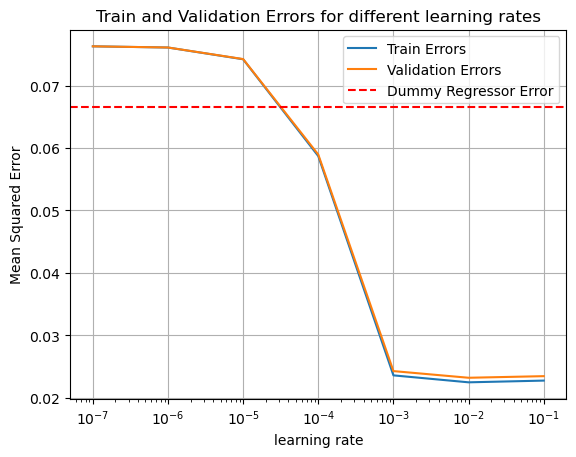

In [15]:
# def param grid
lrs = np.logspace(-7, -1, 7) 
# data prep
X_train = s2_train_df.drop(["contamination_level"],axis=1)
y_train = s2_train_df["contamination_level"]

# dict to store results
results = {'lrs': lrs, 'train_errors': [], 'valid_errors': []}

# CV for each learing rate
for lr in lrs:
    model = LinearRegressor(lr= lr)
    
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
    
    # Store results
    results['train_errors'].append(-cv_results['train_score'].mean())
    results['valid_errors'].append(-cv_results['test_score'].mean())


# Dummy regressor
dummy = DummyRegressor()
dummy_cv_results = cross_validate(dummy, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
dummy_valid_error = -dummy_cv_results['test_score'].mean()
# Plot train and validation errors
plt.semilogx(results['lrs'], results['train_errors'], label='Train Errors')
plt.semilogx(results['lrs'], results['valid_errors'], label='Validation Errors')
plt.axhline(y=dummy_valid_error, color='r', linestyle='--', label='Dummy Regressor Error')

# Add labels and legend
plt.xlabel('learning rate')
plt.ylabel('Mean Squared Error')
plt.title('Train and Validation Errors for different learning rates')
plt.legend()
plt.grid()
plt.show()



In [16]:
# Getting index of the min validation error
best_index = np.argmin(results['valid_errors'])
best_lr = results['lrs'][best_index]
best_error = results['valid_errors'][best_index]

print(f"Optimal learning rate: {best_lr}")
print(f"Validation error at optimal learning rate: {best_error}")


Optimal learning rate: 0.01
Validation error at optimal learning rate: 0.023206892546040265


* Training LinearRegressor on entire data with optimal Learning rate = 0.01

In [17]:
linear_regressor = LinearRegressor(lr = best_lr).fit(X = s2_entire_train_df.drop(["contamination_level"],axis=1),
                                      y = s2_entire_train_df["contamination_level"])

# Section 3: Lasso linear regression

In [18]:
from sklearn.linear_model import Lasso

* Question 7 

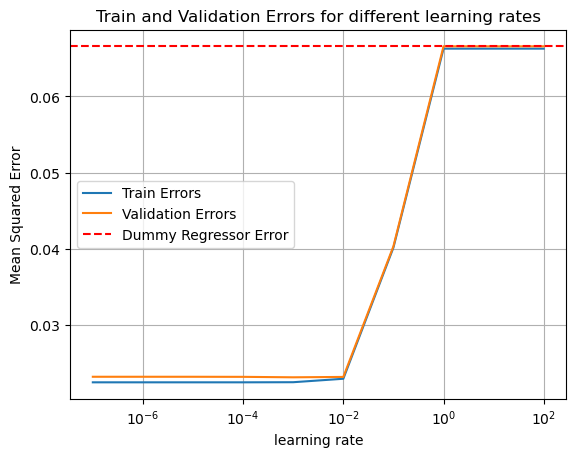

In [26]:
# def param grid
alphas = np.logspace(-7, 2, 10) 
# data prep
X_train = s2_train_df.drop(["contamination_level"],axis=1)
y_train = s2_train_df["contamination_level"]

# dict to store results
results = {'alphas': alphas, 'train_errors': [], 'valid_errors': []}

# CV for each learing rate
for alpha in alphas:
    model = Lasso(alpha=alpha)
    
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
    
    # Store results
    results['train_errors'].append(-cv_results['train_score'].mean())
    results['valid_errors'].append(-cv_results['test_score'].mean())


# Dummy regressor
dummy = DummyRegressor()
dummy_cv_results = cross_validate(dummy, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
dummy_valid_error = -dummy_cv_results['test_score'].mean()
# Plot train and validation errors
plt.semilogx(results['alphas'], results['train_errors'], label='Train Errors')
plt.semilogx(results['alphas'], results['valid_errors'], label='Validation Errors')
plt.axhline(y=dummy_valid_error, color='r', linestyle='--', label='Dummy Regressor Error')

# Add labels and legend
plt.xlabel('learning rate')
plt.ylabel('Mean Squared Error')
plt.title('Train and Validation Errors for different learning rates')
plt.legend()
plt.grid()
plt.show()



In [27]:
# Getting index of the min validation error
best_index = np.argmin(results['valid_errors'])
best_alpha = results['alphas'][best_index]
best_error = results['valid_errors'][best_index]

print(f"Optimal regularization alpha: {best_alpha}")
print(f"Validation error at optimal regularization alpha: {best_error}")


Optimal regularization alpha: 0.001
Validation error at optimal regularization alpha: 0.02313150258151016


* Training Lasso with optimal regularization parameter = 0.001

In [28]:
lasso_regressor = Lasso(alpha=best_alpha).fit(X = s2_entire_train_df.drop(["contamination_level"],axis=1),
                                      y = s2_entire_train_df["contamination_level"])

* Question 9

In [46]:
feature_names = s2_train_df.columns
abs_coefficients = np.abs(lasso_regressor.coef_)
top_5_indecies = np.argsort(abs_coefficients)[-5:][::-1]
top_5_feature_names = feature_names[top_5_indecies]
top_5_feature_names

Index(['PCR_04', 'PCR_02', 'PCR_06', 'PCR_10', 'PCR_09'], dtype='object')

* Question 10

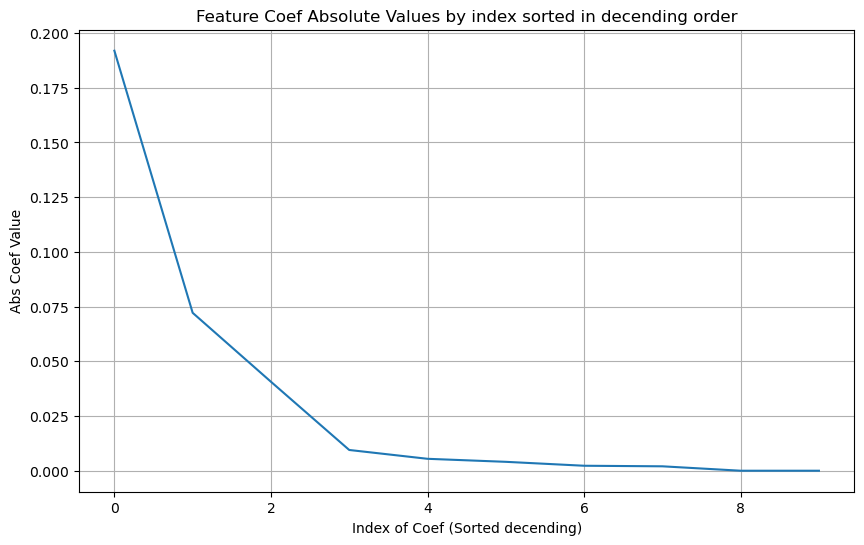

In [50]:
sorted_indices = np.argsort(abs_coefficients)[::-1]
sorted_coefs = abs_coefficients[sorted_indices]

# Plot the sorted absolute values of the coefficients
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sorted_coefs)), sorted_coefs)
plt.xlabel('Index of Coef (Sorted decending)')
plt.ylabel('Abs Coef Value')
plt.title('Feature Coef Absolute Values by index sorted in decending order')
plt.grid(True)
plt.show()